In [1]:
import os
from pathlib import Path
from PIL import Image
from PIL.ImageFile import ImageFile
from typing import TypedDict, final

import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

from random import randint

from ultralytics import YOLO
from ultralytics.engine.results import Results

import cv2

from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
DATA_DIR = Path("./cv-4-objectdetection/craters/")
RESULTS_DIR = Path("./results/")

In [3]:
model = YOLO("yolo11s.pt")

train_results = model.train(
    data=DATA_DIR / "craters.yaml", imgsz=640, epochs=100,
    flipud=0.5,       # вертикальный флип с вероятностью 0.5
    fliplr=0.5,       # горизонтальный флип
    hsv_h=0.015,      # изменение оттенка
    hsv_s=0.7,        # насыщенность
    hsv_v=0.4,        # яркость
    degrees=10.0,     # случайный поворот
    workers=11,
    lr0=1e-3,
    lrf=0.01,
    optimizer="AdamW",
)

Ultralytics 8.3.228 🚀 Python-3.13.5 torch-2.8.0+rocm6.3 CUDA:0 (AMD Radeon Graphics, 8176MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cv-4-objectdetection/craters/craters.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, persp

In [5]:
model.save("bestS.pt")

In [13]:


class CraterLabel(TypedDict):
    class_id: str
    bbox: tuple[int, int, int, int]

@final
class CraterDataset:
    def __init__(self, dir: Path):
        self.dir = dir
        self.ids = [f.stem for f in (dir / "labels").iterdir()]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx: int) -> tuple[ImageFile, list[CraterLabel]]:
        image_path = self.dir / "images" / (self.ids[idx] + ".jpg")
        image = Image.open(image_path)
        width, height = image.size

        label_path = self.dir / "labels" / (self.ids[idx] + ".txt")
        with open(label_path) as file:
            lines = file.readlines()

        labels: list[CraterLabel] = []
        for line in lines:
            class_id, *cords = line.split()
            x_center, y_center, w, h = map(float, cords)

            x_center *= width
            y_center *= height
            w *= width
            h *= height
            
            x1 = int(x_center - w/2)
            y1 = int(y_center - h/2)
            x2 = int(x_center + w/2)
            y2 = int(y_center + h/2)

            labels.append({
                "class_id" : class_id,
                "bbox" : (x1, y1, x2, y2)
            })

        return image, labels

def dice_score(pred_mask, true_mask):
    pred = pred_mask
    true = true_mask
    intersection = np.logical_and(pred, true).sum()
    dice = (2. * intersection) / (pred.sum() + true.sum() + 1e-8)
    return dice

def median_dice_score(model: YOLO, dataset: CraterDataset, conf: float) -> float:
    scores = []
    for id in range(len(dataset)):
        image, labels = dataset[id]
        width, height = image.size

        mask_true = make_mask_for_label(width, height, labels)

        # plt.imshow(image)
        # plt.show()
        # plt.imshow(mask)
        # plt.show()

        results = model.predict(np.array(image), conf=conf, verbose=False)[0]

        mask_pred = np.zeros((height, width))
        if results.boxes is not None:
            for box in results.boxes.xyxy.cpu().numpy():
                x1, y1, x2, y2 = box.astype(int)
                mask_pred[y1:y2, x1:x2] = 1

        # plt.imshow(mask_pred)
        # plt.show()

        scores.append(dice_score(mask_pred, mask_true))

    return sum(scores) / len(scores)

def make_mask_for_label(width: int, height: int, labels: list[CraterLabel]):
    mask = np.zeros((width, height), dtype=np.bool)

    for label in labels:
        x1, y1, x2, y2 = label["bbox"]
        mask[y1:y2, x1:x2] = 1

    return mask

def make_mask_for_prediction(width: int, height: int, predictions: Results):
    boxes = predictions.boxes.xyxy.cpu().numpy()
    mask = np.zeros((width, height), dtype=np.bool)
    
    for i, box in enumerate(boxes.astype(np.int32)):
        x1, y1, x2, y2 = box
        mask[y1:y2, x1:x2] = 1

    return mask


def show_item_with_predictions(
    image,
    labels: list[CraterLabel],
    predictions: Results | None = None,
    color_label: tuple[int,int,int]=(0,255,0),
    color_pred: tuple[int,int,int]=(255,0,0),
    figsize=(10,10)
):
    if not isinstance(image, np.ndarray):
        image_cv = np.array(image)
    else:
        image_cv = image.copy()
    
    for label in labels:
        x1, y1, x2, y2 = label["bbox"]
        cv2.rectangle(image_cv, (x1, y1), (x2, y2), color_label, 2)
        cv2.putText(image_cv, f"Label {label['class_id']}", 
                    (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_label, 1, cv2.LINE_AA)
    
    if predictions is not None:
        boxes = predictions.boxes.xyxy.cpu().numpy()
        scores = predictions.boxes.conf.cpu().numpy()
        
        for i, box in enumerate(boxes.astype(np.int32)):
            x1, y1, x2, y2 = box
            cv2.rectangle(image_cv, (x1, y1), (x2, y2), color_pred, 2)
            cv2.putText(image_cv, f"{scores[i]:.2f}", 
                        (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_pred, 1, cv2.LINE_AA)    

    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(image_cv)
    plt.show() 


In [4]:
train_dataset = CraterDataset(DATA_DIR / "train")
val_dataset = CraterDataset(DATA_DIR / "valid")

In [26]:
low, high, step = 0.05, 0.95, 0.03
thresholds: list[float] = []
dice_means: list[float] = []
conf = low
while conf <= high:
    thresholds.append(conf)
    dice_means.append(median_dice_score(model, val_dataset, conf))

    conf += step

result = pd.DataFrame({"conf": thresholds, "dice_score": dice_means})

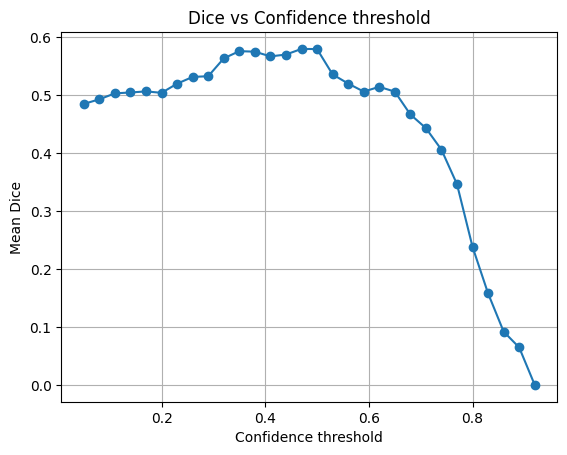

In [27]:
plt.plot(result["conf"], result["dice_score"], marker="o")
plt.title("Dice vs Confidence threshold")
plt.xlabel("Confidence threshold")
plt.ylabel("Mean Dice")
plt.grid(True)


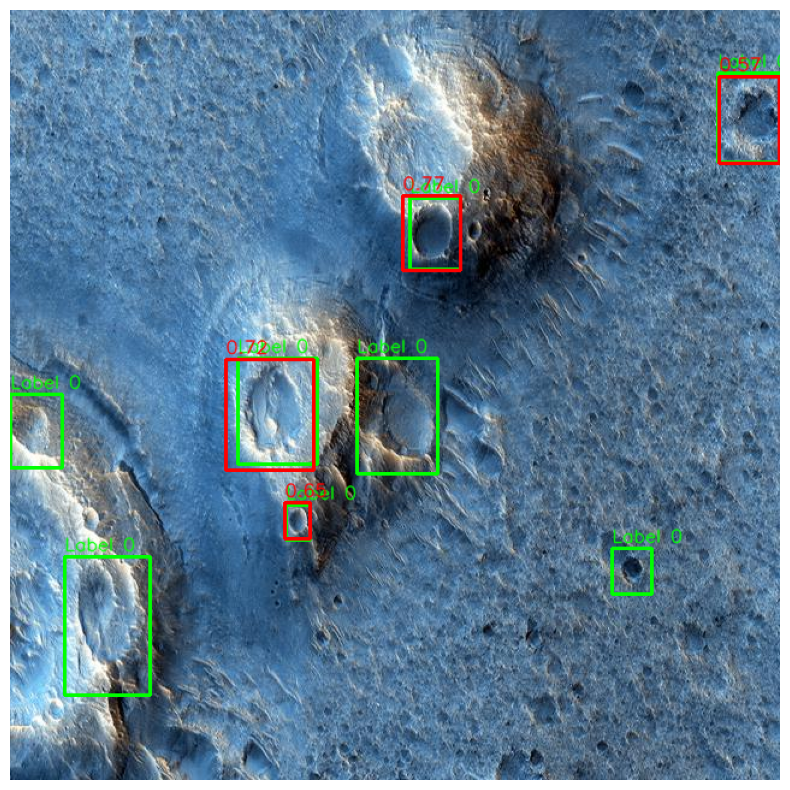

In [ ]:
rand_id = randint(0, len(train_dataset))
image, labels = train_dataset[rand_id]
predictions = model.predict(np.array(image), conf=0.5)[0]
show_item_with_predictions(image, labels, predictions)

In [5]:
model = YOLO("./bestS.pt")

In [19]:
def rle_encode_tensor(mask: np.ndarray):
    """
    Encode a PyTorch binary mask tensor into Kaggle-style RLE string.

    Args:
        mask_tensor: torch.Tensor of shape (H, W) or (1, H, W)
                     dtype: bool, int, or float (will be thresholded at 0.5 if float)

    Returns:
        str: RLE string (e.g., "1 3 10 5 ...") or empty string if no foreground
    """
    # Убираем лишние измерения
    if mask.ndim == 3:
        if mask.shape[0] == 1:
            mask = mask.squeeze(0)
        else:
            raise ValueError("Expected single-channel mask, got shape: {}".format(mask.shape))

    # Бинаризуем, если нужно
    if mask.dtype == np.float32 or mask.dtype == np.float64:
        mask = mask > 0.5
    else:
        mask = mask.astype(bool)

    # Проверка на пустую маску
    if mask.sum() == 0:
        return ""

    # RLE в column-major порядке (Kaggle стандарт)
    pixels = mask.T.flatten()  # <-- ВАЖНО: .T для column-major
    pixels = np.concatenate([[0], pixels, [0]])  # паддинг
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]

    return ' '.join(str(x) for x in runs)

In [36]:
train_dir = DATA_DIR / "test" / "images"
conf = 0.25

rows = []
for image_path in train_dir.iterdir():
    image = np.array(Image.open(image_path))
    width, height, *_ = image.shape

    predictions = model(image, conf=conf)[0]
    mask = make_mask_for_prediction(width, height, predictions)

    rle_encode = rle_encode_tensor(mask)
    rows.append({
        "FILE_NAME":image_path.name, 
        "TARGET": rle_encode
    })

df = pd.DataFrame(rows).sort_values("FILE_NAME")
df.head()

,FILE_NAME,TARGET
17,010_png.rf.fcf5e274562ee69a325f9d7a0b30767f.jpg,501 101 1141 101 1781 101 2421 101 3061 101 37...
30,015_png.rf.7d5b2091b6339c9480a171a59c52c3b9.jpg,59 245 699 245 1339 245 1979 245 2619 245 3259...
1,019_png.rf.1930cd277f9bf0e3fa57f2dcfee0385f.jpg,155 197 795 197 1435 197 2075 197 2715 197 335...
12,04_png.rf.81a7d6cbeb9dc09e5a8ecd40e185fc92.jpg,11451 53 12091 53 12731 53 13371 53 14011 53 1...
15,Lunar_A_0-0_png_jpg.rf.74e92e6bd5b9fbe3cae163f...,1614 179 2254 179 2894 179 3534 179 4174 179 4...


In [37]:
df.to_csv("submishin.csv", index=False)